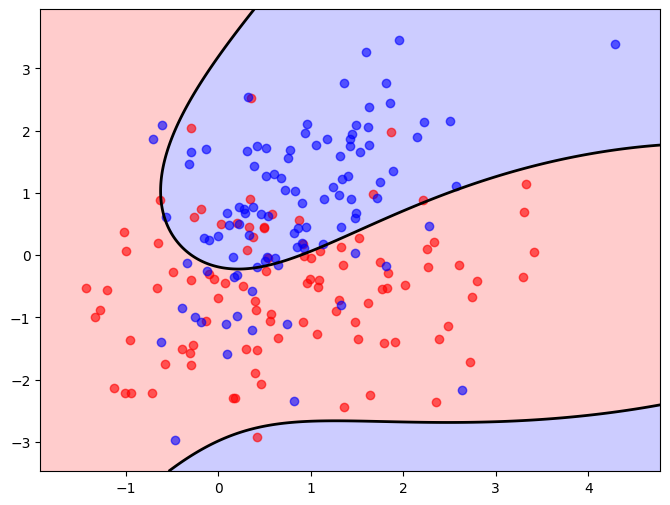

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)

x, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.1,
    random_state=42,
)

poly = PolynomialFeatures(degree=3, include_bias=False)
x_poly = poly.fit_transform(x)

num_samples, num_features = x_poly.shape
w = np.zeros((1, num_features))
b = 0
learning_rate = 0.5
iterations = 1500
lambda_reg = 1.0  
cost_history = []

for i in range(iterations):
    z = w @ x_poly.T + b
    y_pred = 1 / (1 + np.exp(-z))
    
    error = y_pred - y.T
    
    djdw = (1 / num_samples) * (error @ x_poly) + (lambda_reg / num_samples) * w
    djdb = (1 / num_samples) * np.sum(error)
    
    w = w - learning_rate * djdw
    b = b - learning_rate * djdb
    
    reg_cost = (lambda_reg / (2 * num_samples)) * np.sum(w ** 2)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    cost = - (1 / num_samples) * np.sum(y.T * np.log(y_pred) + (1 - y.T) * np.log(1 - y_pred)) + reg_cost
    cost_history.append(cost)

x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid_points)

z_grid = w @ grid_poly.T + b
preds_grid = 1 / (1 + np.exp(-z_grid))
preds_grid = preds_grid.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds_grid, levels=[0, 0.5, 1], alpha=0.2, colors=['red', 'blue'])
plt.contour(xx, yy, preds_grid, levels=[0.5], colors='black', linewidths=2)
plt.scatter(x[y == 0, 0], x[y == 0, 1], color="red", alpha=0.6)
plt.scatter(x[y == 1, 0], x[y == 1, 1], color="blue", alpha=0.6)
plt.show()